In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

# Linear Regression

In [2]:
X = np.array([1,3,4])
y = np.array([2,4,8])
X.shape, y.shape

((3,), (3,))

In [3]:
w = 1.5
b = 1

# Predict $\hat{y}$

In [4]:
def predict_y(X, w, b):
    m = X.shape[0]
    y_hat = np.zeros(m)

    for i in range(m):
        y_hat[i] = w * X[i] + b
    return y_hat

In [5]:
predict_y(X, w, b)

array([2.5, 5.5, 7. ])

In [6]:
def plot_real_vs_prediction(X, w, b):
    y_hat = predict_y(X, w, b)
    plt.scatter(X, y, label="real y")
    plt.plot(X,y_hat, label = "y_hat")
    plt.title("real vs predicted")
    plt.legend()

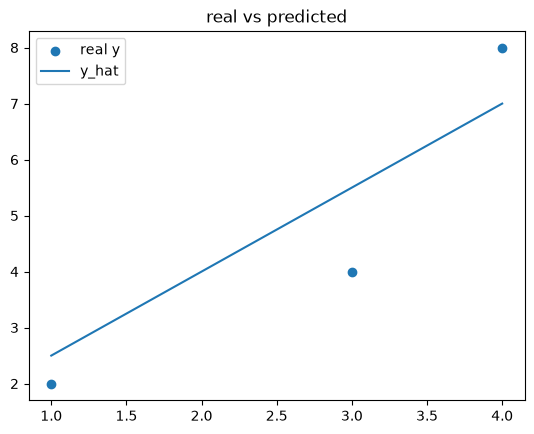

In [7]:
plot_real_vs_prediction(X, w, b)

# Mean square error
$$
MSE = 1/2m \sum_{i=1}^m (\hat{y} - y ) ^ 2
$$

## Calculate MSE

In [8]:
def calculate_mse(X, y, w, b):
    y_hat = predict_y(X, w, b)
    m = X.shape[0]
    sum  = np.sum((y_hat - y) ** 2)
    mse = (1/(2*m)) * sum
    return mse

In [9]:
calculate_mse(X, y, w, b)

np.float64(0.5833333333333333)

## Cost function
$$
J(w,b) =  1 / (2m) * \sum_{i=1}^n (\hat{y_i} - y_i ) ^ 2
$$
#### Although similar to cost function we can pass different w and b so see how the cost function behave Then we can use gradient descent to find local minima of the cost function. Thus obtained w and b will be optimal solution for our model

In [10]:
def gradient(X, y, w, b):
    m = X.shape[0]
    dj_dw = (1 / m) * np.sum((w * X + b - y) * X)
    dj_db = (1 / m) * np.sum(w * X + b - y)
    return (dj_dw, dj_db)

In [11]:
def gradient_descent(X, y, w, b, iters=1000, alpha=0.01, history_interval=100):
    history = {}
    for i in range(iters):
        dj_dw, dj_db = gradient(X, y, w, b)
        w -= alpha * dj_dw
        b -= alpha * dj_db
        if i % history_interval == 0:
            print(f"w {w}, b {b}")
            cost = calculate_mse(X, y, w, b)
            history[i] = cost;
            print(f"{i} => {cost}")
    return w, b
            

In [12]:
w_new, b_new = gradient_descent(X,y,w,b)

w 1.4966666666666666, b 0.9966666666666667
0 => 0.5811944444444446
w 1.518912141037045, b 0.7927796168922542
100 => 0.5331333459418242
w 1.5700206654454913, b 0.6298080473591114
200 => 0.5039202524118163
w 1.6134076705560356, b 0.4914635607214387
300 => 0.4828688764164708
w 1.6502384698064088, b 0.3740242954074911
400 => 0.4676989516331068
w 1.6815037707287952, b 0.2743312655282415
500 => 0.45676728531429633
w 1.708044575209364, b 0.18970283925244627
600 => 0.44888976909636125
w 1.7305748014248243, b 0.11786260586208396
700 => 0.4432131174355751
w 1.7497004874488273, b 0.0568781428311565
800 => 0.43912244047771154
w 1.765936093003366, b 0.005109035804988671
900 => 0.43617463973644127


In [13]:
print(f"Old mse {calculate_mse(X, y, w, b)}")
print(f"New mse {calculate_mse(X, y, w_new, b_new)}")

Old mse 0.5833333333333333
New mse 0.434068393450958


In [14]:
y_hat = predict_y(X, w_new, b_new)

In [15]:
y_hat

array([1.74115893, 5.30034171, 7.0799331 ])

In [16]:
y

array([2, 4, 8])

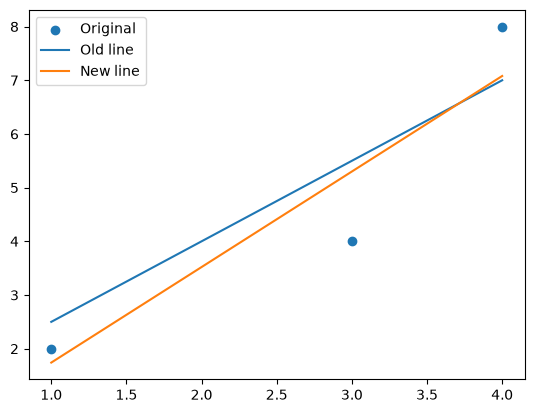

In [17]:
y_hat_old = predict_y(X, w, b)
y_hat_new = predict_y(X, w_new, b_new)
plt.scatter(X, y, label="Original")
plt.plot(X, y_hat_old, label="Old line")
plt.plot(X, y_hat_new, label="New line")
plt.legend()
plt.show()

# Fitting for large data set

In [18]:
m = 20
target_m = 4.4
target_b = 5
X = np.random.uniform(-10, 10, m)
noise = np.random.uniform(-3,3, m)
Y = X*target_m + target_b + noise
w = 3
b = 9

In [19]:
w_new, b_new = gradient_descent(X, Y, w, b, 10000)

w 3.4363251498719443, b 8.947723470961312
0 => 26.146491312469625
w 4.4828726583864364, b 6.478961425245485
100 => 2.066247674092615
w 4.45364399068501, b 5.563342684428769
200 => 1.1656968265589505
w 4.442643705096525, b 5.218747174909222
300 => 1.0381416405350492
w 4.4385037188246805, b 5.089057753005169
400 => 1.0200745591191007
w 4.436945624155848, b 5.04024879964052
500 => 1.0175155143552972
w 4.436359231149291, b 5.0218794222959655
600 => 1.0171530479473372
w 4.436138540606531, b 5.0149660590548875
700 => 1.0171017077368192
w 4.436055483143158, b 5.012364196705031
800 => 1.0170944358430425
w 4.436024224249435, b 5.01138497899991
900 => 1.0170934058426095
w 4.43601245988297, b 5.011016447853722
1000 => 1.0170932599520175
w 4.436008032332859, b 5.010877750192309
1100 => 1.017093239287885
w 4.436006366012788, b 5.010825550964428
1200 => 1.017093236360991
w 4.436005738888867, b 5.010805905648392
1300 => 1.0170932359464209
w 4.436005502869139, b 5.010798512082292
1400 => 1.01709323588

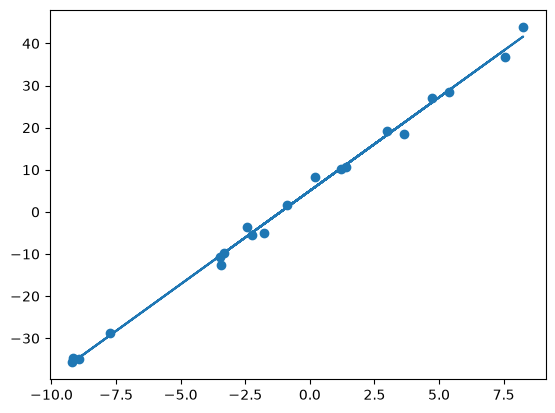

In [20]:
plt.scatter(X, Y)
plt.plot(X, predict_y(X, w_new, b_new))

In [21]:
w_new, b_new

(np.float64(4.4360053604382665), np.float64(5.010794050285446))

## Multiple Linear Regression
$$
    \hat{y}_i = x1_i * w1_i + x2_i * w2_i + b
$$

In [23]:
x = np.array(
    [
        [1,2],
        [2,1],
        [3,1],
        [1,3]
    ]
)

In [24]:
y = np.array([3,6,8,7])

In [72]:
w = np.array([3,2])
b = -3

In [73]:
def predict_y(x, w,b):
    m = x.shape[0]
    y_hat = np.zeros(m)

    for i in range(m):
        y_hat[i] = np.dot(w,x[i]) + b
    return y_hat

In [74]:
y_hat = predict_y(x, w,b)

In [75]:
y_hat, y

(array([4., 5., 8., 6.]), array([3, 6, 8, 7]))

In [76]:
def calculate_mse(X, y, w, b):
    y_hat = predict_y(X, w, b)
    m = X.shape[0]
    sum  = np.sum((y_hat - y) ** 2)
    mse = (1/(2*m)) * sum
    return mse

In [77]:
def gradient_step(x,y,w,b):
    m = x.shape[0]
    n = x.shape[1]
    dj_dw = np.zeros(n)
    dj_db = 0
    for i in range(m):
        err = np.dot(w,x[i]) + b - y[i]

        dj_dw += err * x[i]
        dj_db += err

    dj_dw /= m
    dj_db /= m
    return dj_dw, dj_db    

In [78]:
def gradient_descent(X, y, w, b, iters=10000, alpha=0.01, history_interval=100):
    history = {}
    for i in range(iters):
        dj_dw, dj_db = gradient_step(X, y, w, b)
        w = w - np.dot(alpha , dj_dw)
        b = b - alpha * dj_db
        if i % history_interval == 0:
            print(f"w {w}, b {b}")
            cost = calculate_mse(X, y, w, b)
            history[i] = cost;
            print(f"{i} => {cost}")
    return w, b

In [79]:
dj_dw, dj_db = gradient_step(x, y, w, b)

In [80]:
w_new , b_new = gradient_descent(x,y,w,b)

w [3.005 2.005], b -2.9975
0 => 0.3695781250000002
w [3.07553785 2.07553785], b -2.988398597493384
100 => 0.33535859556971526
w [3.08284531 2.08284531], b -3.014281604348719
200 => 0.33458190815033123
w [3.0899935 2.0899935], b -3.039740208334902
300 => 0.3338316203449795
w [3.09701919 2.09701919], b -3.064762575416157
400 => 0.33310682543576287
w [3.10392449 2.10392449], b -3.089356170268211
500 => 0.33240665723806284
w [3.11071147 2.11071147], b -3.113528340136925
600 => 0.33173027899804464
w [3.11738215 2.11738215], b -3.1372863063747545
700 => 0.3310768823926673
w [3.12393852 2.12393852], b -3.160637166592245
800 => 0.33044568656367834
w [3.13038254 2.13038254], b -3.1835878967784246
900 => 0.329835937184428
w [3.13671614 2.13671614], b -3.206145353384855
1000 => 0.3292469055583921
w [3.14294121 2.14294121], b -3.2283162753739667
1100 => 0.3286778877483262
w [3.14905962 2.14905962], b -3.2501072862323124
1200 => 0.328128203735005
w [3.15507317 2.15507317], b -3.271524895949292
1300

In [81]:
print(f"Old {predict_y(x, w, b)} New: {predict_y(x,w_new, b_new)}")
print(f"Original: {y}")

Old [4. 5. 8. 6.] New: [4.04306633 5.04306633 8.46637483 6.46637483]
Original: [3 6 8 7]


In [82]:
data = load_diabetes()

In [83]:
x = data.data

In [84]:
y = data.target

In [85]:
x, y

(array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59.

In [86]:
x.shape

(442, 10)

In [87]:
y.shape

(442,)

In [88]:
m = x.shape[1]
w = np.zeros(m)
b = 0
w,b = gradient_descent(x,y,w,b)

w [ 0.00688197  0.00157727  0.02148044  0.01617055  0.00776594  0.00637522
 -0.0144603   0.01576658  0.02072709  0.01400957], b 1.5213348416289594
0 => 14306.756491598268
w [ 0.69119348  0.1562883   2.16275379  1.62744972  0.778932    0.6384775
 -1.45468709  1.58462309  2.0858232   1.40862921], b 97.00456652263934
100 => 4464.933292224966
w [ 1.3678594   0.30506857  4.29069264  3.22735561  1.53942312  1.2599229
 -2.8834883   3.13812602  4.13593106  2.79077442], b 131.95451736717374
200 => 3129.8300353136724
w [ 2.03695153  0.44797967  6.40540351  4.81598275  2.28934746  1.87082202
 -4.30096179  4.67641738  6.1711793   4.1605549 ], b 144.74732970218292
300 => 2934.7194370574866
w [ 2.69854103  0.58508261  8.50699204  6.39342485  3.02881221  2.47128441
 -5.70720454  6.19963788  8.19169538  5.51807941], b 149.42991275263543
400 => 2892.605148815783
w [ 3.35269839  0.71643785 10.59556292  7.95977481  3.75792352  3.06141859
 -7.10231269  7.70792697 10.19760565  6.86345568], b 151.1438895897

In [89]:
y_hat = predict_y(x,w,b)

In [90]:
y_hat[:10]

array([168.82057098, 109.96870073, 160.22537849, 153.29351324,
       139.65930002, 108.39537449, 121.39227062, 162.48396288,
       159.86585338, 161.77346184])

In [91]:
y[:10]

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310.])